In [1]:
from google.colab import files

uploaded = files.upload()

Saving WineQT.csv to WineQT.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('WineQT.csv')
print(df.shape)
df.head()

(1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
df = df.drop('Id',axis = 1)

In [5]:
print(df["quality"].value_counts().sort_index())

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


In [6]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [9]:
print(df.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


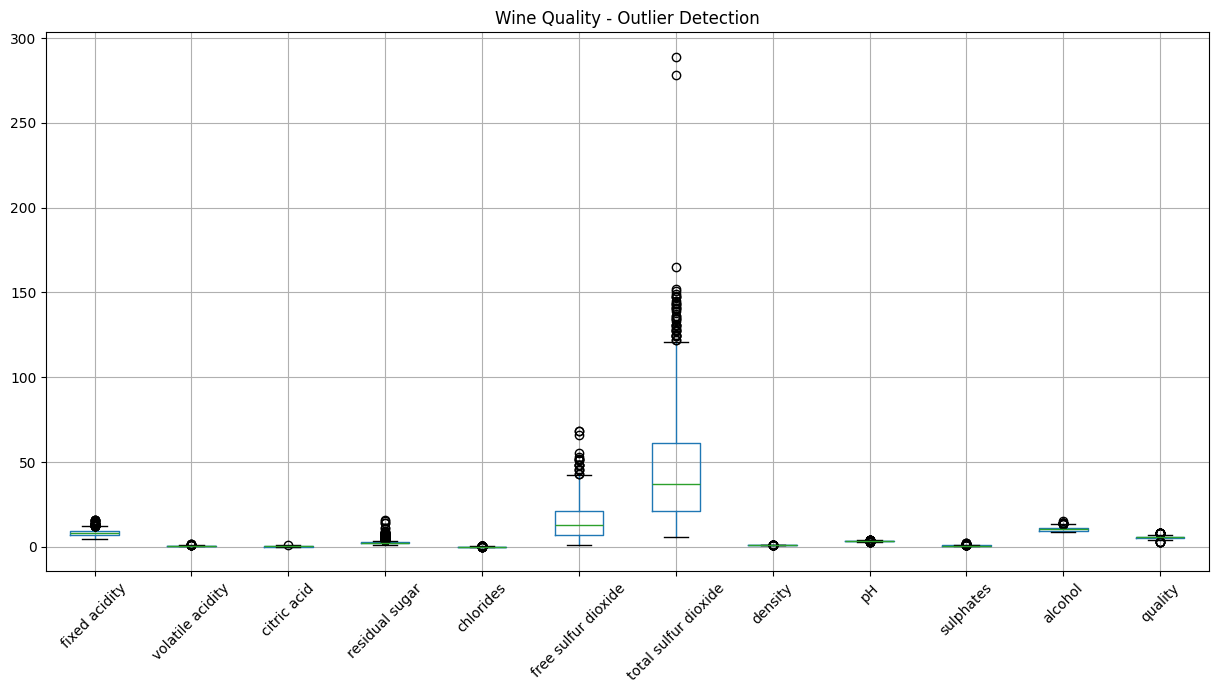

In [10]:
plt.figure(figsize=(15,7))
df.boxplot()
plt.xticks(rotation = 45)
plt.title("Wine Quality - Outlier Detection")
plt.show()

In [11]:
print(df.describe().T)

                       count       mean  ...        75%        max
fixed acidity         1143.0   8.311111  ...   9.100000   15.90000
volatile acidity      1143.0   0.531339  ...   0.640000    1.58000
citric acid           1143.0   0.268364  ...   0.420000    1.00000
residual sugar        1143.0   2.532152  ...   2.600000   15.50000
chlorides             1143.0   0.086933  ...   0.090000    0.61100
free sulfur dioxide   1143.0  15.615486  ...  21.000000   68.00000
total sulfur dioxide  1143.0  45.914698  ...  61.000000  289.00000
density               1143.0   0.996730  ...   0.997845    1.00369
pH                    1143.0   3.311015  ...   3.400000    4.01000
sulphates             1143.0   0.657708  ...   0.730000    2.00000
alcohol               1143.0  10.442111  ...  11.100000   14.90000
quality               1143.0   5.657043  ...   6.000000    8.00000

[12 rows x 8 columns]


In [14]:
for col in df.select_dtypes(include="number").columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

fixed acidity: 44 outliers
volatile acidity: 14 outliers
citric acid: 1 outliers
residual sugar: 110 outliers
chlorides: 77 outliers
free sulfur dioxide: 18 outliers
total sulfur dioxide: 40 outliers
density: 36 outliers
pH: 20 outliers
sulphates: 43 outliers
alcohol: 12 outliers
quality: 22 outliers


In [15]:
x = df.drop("quality", axis=1)
y = df["quality"]

In [16]:
feature_cols = df.drop("quality", axis=1).columns

for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower, upper=upper)

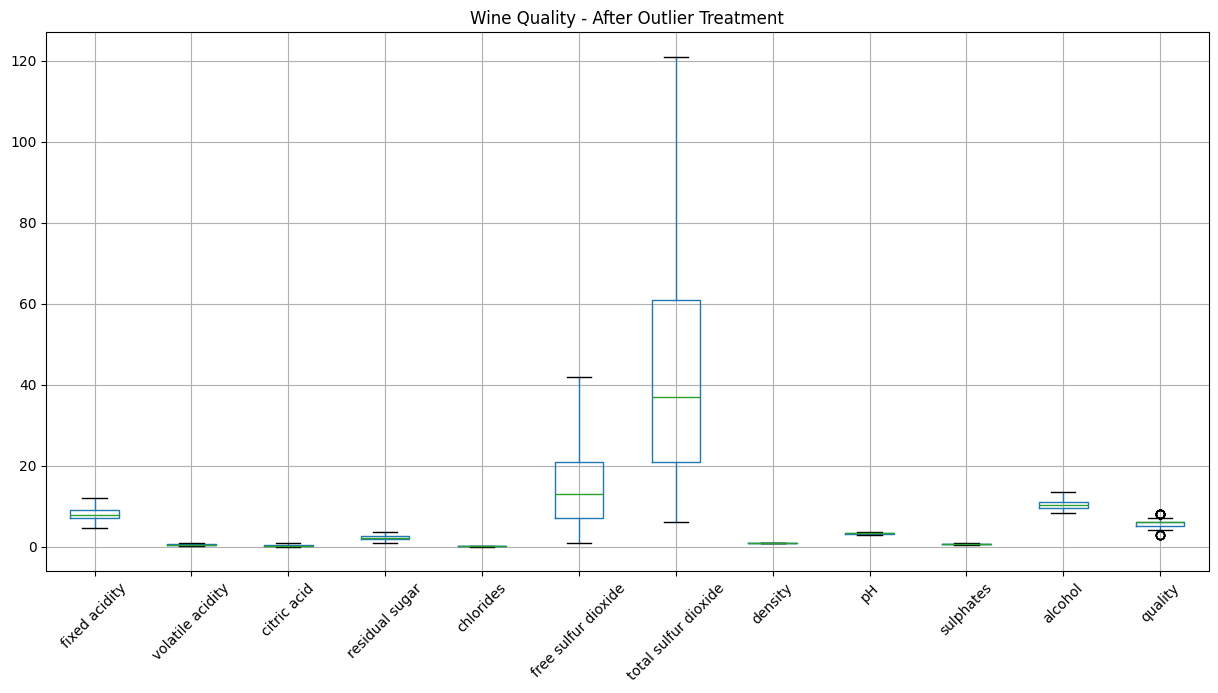

In [18]:
plt.figure(figsize=(15, 7))

df.boxplot()

plt.title("Wine Quality - After Outlier Treatment")
plt.xticks(rotation=45)
plt.show()

In [19]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
ss = StandardScaler()
x_train = ss.fit_transform(x_train)
x_test = ss.transform(x_test)

In [21]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train, y_train)

lr_pred = lr.predict(x_test)

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, lr_pred)
mse = mean_squared_error(y_test, lr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lr_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.4773398352588606
MSE : 0.38003245026277516
RMSE: 0.6164677203737233
R²  : 0.3170693672733129


In [24]:
print("Actual:   ", y_test.values[:10])
print("Predicted:", lr_pred[:10])

Actual:    [5 6 5 6 6 8 5 5 6 5]
Predicted: [5.37639096 4.81275231 5.26822711 5.08826518 6.09668676 6.60433542
 5.36417303 5.06978794 5.78461148 5.32382095]


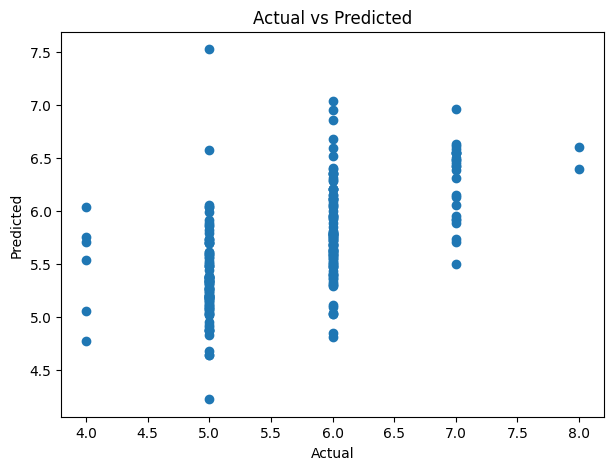

In [25]:
plt.figure(figsize = (7,5))
plt.scatter(y_test, lr_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [34]:
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)

In [35]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

MAE : 0.4277962039127767
MSE : 0.3059846922693528
RMSE: 0.5531588309602883
R²  : 0.4501355888116948


In [40]:
from sklearn.model_selection import RandomizedSearchCV
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [300, 500, 700, 1000],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [0.5, 0.7, 0.8, 1.0]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(x_train, y_train)
print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest CV RMSE:")
print(-rf_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 15}

Best CV RMSE:
0.610663520929826


In [41]:
best_rf = rf_search.best_estimator_

rf_pred = best_rf.predict(x_test)

mae = mean_absolute_error(y_test, rf_pred)
mse = mean_squared_error(y_test, rf_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rf_pred)

print("\nTest Results")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)


Test Results
MAE : 0.41063040943543805
MSE : 0.2904506081739511
RMSE: 0.538934697504207
R²  : 0.47805084150331856


In [43]:
gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    loss="huber",
    random_state=42
)
gbr.fit(x_train, y_train)

gbr_pred = gbr.predict(x_test)

In [44]:
mae = mean_absolute_error(y_test, gbr_pred)
mse = mean_squared_error(y_test, gbr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, gbr_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.4355699185327363
MSE : 0.3329546618589988
RMSE: 0.5770222368843325
R²  : 0.40166967916702945


In [45]:
gbr = GradientBoostingRegressor(
    random_state=42
)

param_grid = {
    "n_estimators": [100, 200, 300, 500, 700, 1000],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 6],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "max_features": [None, "sqrt", "log2"]
}

gbr_search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_grid,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

gbr_search.fit(x_train, y_train)
print("Best Parameters:")
print(gbr_search.best_params_)

print("\nBest CV RMSE:")
print(-gbr_search.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters:
{'subsample': 0.6, 'n_estimators': 700, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5, 'learning_rate': 0.03}

Best CV RMSE:
0.6238214608724373


In [46]:
mae = mean_absolute_error(y_test, gbr_pred)
mse = mean_squared_error(y_test, gbr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, gbr_pred)

print("Gradient Boosting Results")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Gradient Boosting Results
MAE : 0.4355699185327363
MSE : 0.3329546618589988
RMSE: 0.5770222368843325
R²  : 0.40166967916702945


In [48]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb.fit(x_train, y_train)
xgb_pred = xgb.predict(x_test)
mae = mean_absolute_error(y_test, xgb_pred)
mse = mean_squared_error(y_test, xgb_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

XGBoost Results
MAE : 0.42842555046081543
MSE : 0.3251871168613434
RMSE: 0.5702518012784733
R²  : 0.41562825441360474


In [49]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [200, 300, 500, 700, 1000],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08],
    "max_depth": [2, 3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 7, 10],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.5, 0.6, 0.7, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5, 1],
    "reg_alpha": [0, 0.01, 0.1, 0.3, 0.5],
    "reg_lambda": [0.5, 1, 2, 5, 10]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(x_train, y_train)
print("Best Parameters:")
print(xgb_search.best_params_)

print("\nBest CV RMSE:")
print(-xgb_search.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters:
{'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0.3, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.5}

Best CV RMSE:
0.6155134320259095


In [50]:
best_xgb = xgb_search.best_estimator_

xgb_pred = best_xgb.predict(x_test)

mae = mean_absolute_error(y_test, xgb_pred)
mse = mean_squared_error(y_test, xgb_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, xgb_pred)

print("\nTuned XGBoost Results")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)


Tuned XGBoost Results
MAE : 0.4129146933555603
MSE : 0.29002097249031067
RMSE: 0.5385359528298094
R²  : 0.4788229465484619
